Title: capacity_data_offshore.ipynb

Purpose: Transform the xml capacity data into some gridded format (The gross power output as well as the hub height)

Author: Onno Nennecke on 10.02.2025 Modified: 11.03.2025

Input data: 

    - This file lies here: 

Output data:

    - This file lies here: 

In [ ]:
import pandas as pd
import geopandas as gpd
import xml.etree.ElementTree as ET
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import Functions.grid_func as grid_func # Own function to create 1x1 degree grid

In [2]:
# Load the XML file
tree = ET.parse('/climca/people/onennecke/Wind_Solar_MaStR/EinheitenWind.xml')
root = tree.getroot()


Felder relevant:
columns_to_keep = ['EinheitMastrNummer', 'Postleitzahl', 'Bruttoleistung', 'Nettonennleistung',
  'Lage', 'NameWindpark', 'Nabenhoehe', 'Rotordurchmesser', 
  'Seelage', 'ClusterNordsee', 'Wassertiefe', 'Kuestenentfernung', 'ClusterOstsee', 'Laengengrad',
  'Breitengrad']

Liste Felder nicht relevant:
columns_to_loose = ['DatumLetzteAktualisierung', 'LokationMaStRNummer',
       'NetzbetreiberpruefungStatus', 'AnlagenbetreiberMastrNummer', 'Land', 
       'Bundesland', 'Landkreis', 'Gemeinde', 'Gemeindeschluessel', 'Ort',
       'Registrierungsdatum', 'Inbetriebnahmedatum', 'EinheitSystemstatus',
       'EinheitBetriebsstatus', 'NichtVorhandenInMigriertenEinheiten',
       'NameStromerzeugungseinheit', 'Weic_nv', 'Kraftwerksnummer_nv',
       'Energietraeger', 'FernsteuerbarkeitNb', 'Einspeisungsart', 'EegMaStRNummer',
       'DatumBeginnVoruebergehendeStilllegung', 'NetzbetreiberpruefungDatum',
       'Adresszusatz', 'FernsteuerbarkeitDv', 'DatumDesBetreiberwechsels',
       'DatumRegistrierungDesBetreiberwechsels', 'Gemarkung', 'FlurFlurstuecknummern',
       'AnschlussAnHoechstOderHochSpannung', 
       'DatumEndgueltigeStilllegung', 'Strasse', 'StrasseNichtGefunden', 'Hausnummer_nv',
       'HausnummerNichtGefunden',
       'GenMastrNummer', 'Einsatzverantwortlicher', 'WeicDisplayName',
       'DatumWiederaufnahmeBetrieb', 'GeplantesInbetriebnahmedatum',
       'Buergerenergie', 'Kraftwerksnummer','Hersteller', 'Technologie', 'Typenbezeichnung',
       'Rotorblattenteisungssystem', 'AuflageAbschaltungLeistungsbegrenzung',
       'AuflagenAbschaltungSchallimmissionsschutzNachts',
       'AuflagenAbschaltungSchallimmissionsschutzTagsueber',
       'AuflagenAbschaltungSchattenwurf', 'AuflagenAbschaltungTierschutz',
       'AuflagenAbschaltungEiswurf', 'AuflagenAbschaltungSonstige',
       'Nachtkennzeichnung','Hausnummer']

In [3]:
rows = []

for einheit in root.findall('EinheitWind'):
        einheit_data = {
            'EinheitMastrNummer': einheit.find('EinheitMastrNummer').text,
            'Bruttoleistung': float(einheit.find('Bruttoleistung').text),
            'Nettonennleistung': float(einheit.find('Nettonennleistung').text),
            'Lage': int(einheit.find('Lage').text) if einheit.find('Lage') is not None else np.nan,
            'NameWindpark': einheit.find('NameWindpark').text if einheit.find('NameWindpark') is not None else np.nan,
            'Nabenhoehe': float(einheit.find('Nabenhoehe').text) if einheit.find('Nabenhoehe') is not None else np.nan,
            'Rotordurchmesser': float(einheit.find('Rotordurchmesser').text) if einheit.find('Rotordurchmesser') is not None else np.nan,
            'Seelage': int(einheit.find('Seelage').text) if einheit.find('Seelage') is not None else np.nan,
            # 'ClusterNordsee': int(einheit.find('ClusterNordsee').text) if einheit.find('ClusterNordsee') is not None else np.nan,
            # 'ClusterOstsee': int(einheit.find('ClusterOstsee').text) if einheit.find('ClusterOstsee') is not None else np.nan,
            'Wassertiefe': float(einheit.find('Wassertiefe').text) if einheit.find('Wassertiefe') is not None else np.nan,
            'Kuestenentfernung': float(einheit.find('Kuestenentfernung').text) if einheit.find('Kuestenentfernung') is not None else np.nan,
            'Laengengrad': float(einheit.find('Laengengrad').text) if einheit.find('Laengengrad') is not None else np.nan,
            'Breitengrad': float(einheit.find('Breitengrad').text) if einheit.find('Breitengrad') is not None else np.nan,
            'EinheitBetriebsstatus': int(einheit.find('EinheitBetriebsstatus').text)
        }
        rows.append(einheit_data)


# Convert the list of dictionaries to a DataFrame
df = pd.DataFrame(rows)

# Display the resulting DataFrame
# print(df)

In [4]:
# Drop closed units
print(len(df[df['EinheitBetriebsstatus'] != 35]))
df_1 = df[df['EinheitBetriebsstatus'] == 35].copy() # 35 == In Betrieb

# Drop on-shore units
df_2 = df_1[df_1['Lage'] == 889].copy()

# Drop columns EinheitBetriebsstatus and Lage as they are no longer needed
df_2.drop(columns=['EinheitBetriebsstatus', 'Lage'], inplace=True)

6689


In [5]:
# Some data inspection because of nan values

# df_2['Kuestenentfernung'].isna().sum()

# df_2['Wassertiefe'].isna().sum()

# df_2[df_2['Kuestenentfernung'].isna()]

# All data entries without Wassertiefe and Kuestenentfernung are all in one windpark (not important for further analysis)

In [6]:
# Transform to shapefile
gdf = gpd.GeoDataFrame(df_2, geometry=gpd.points_from_xy(df_2['Laengengrad'], df_2['Breitengrad']))
gdf.crs = 'EPSG:4326'

In [7]:
# Save offshore windpark data as shapefile
# gdf.to_file('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/offshore_windparks.shp')

In [ ]:
# Create a grid
grid = grid_func.create_ref_grid('wind_off_cap')
# grid

In [17]:
# Change coordinates to grid coordinates
gdf["lat_idx"] = np.searchsorted(grid['lat'], gdf["Breitengrad"]) # Zeilenindex für Latitude
gdf["lon_idx"] = np.searchsorted(grid['lon'], gdf["Laengengrad"]) # Spaltenindex für Longitude

# gdf

In [18]:
# print(gdf['Laengengrad'].min())
# print(gdf['Laengengrad'].max())

# print(gdf['Breitengrad'].min())
# print(gdf['Breitengrad'].max())

# print(gdf['lat_idx'].min())
# print(gdf['lat_idx'].max())

# print(gdf['lon_idx'].min())
# print(gdf['lon_idx'].max())

In [19]:
grid_sums = gdf.groupby(["lat_idx", "lon_idx"])["Bruttoleistung"].sum()
# grid_sums

In [20]:
# Write the sums to the grid
for (lat_idx, lon_idx), value in grid_sums.items():
    grid[lat_idx, lon_idx] = value

# Show resulting grid
# print(grid)

In [21]:
# show overall sum
gdf['Bruttoleistung'].sum()

np.float64(9215093.0)

In [25]:
grid = grid.assign_attrs(gridtype='lonlat', crs='EPSG:4326')
grid

<xarray.Dataset> Size: 1kB
Dimensions:       (lat: 10, lon: 12)
Coordinates:
  * lat           (lat) int32 40B 47 48 49 50 51 52 53 54 55 56
  * lon           (lon) int32 48B 5 6 7 8 9 10 11 12 13 14 15 16
Data variables:
    wind_off_cap  (lat, lon) float64 960B ...
Attributes:
    gridtype:  lonlat
    crs:       EPSG:4326

In [ ]:
# Save grid as raster file
grid.to_netcdf('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic.nc')

In [ ]:
grid = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic.nc')
grid

<xarray.Dataset> Size: 1kB
Dimensions:       (lat: 10, lon: 12)
Coordinates:
  * lat           (lat) int32 40B 47 48 49 50 51 52 53 54 55 56
  * lon           (lon) int32 48B 5 6 7 8 9 10 11 12 13 14 15 16
Data variables:
    wind_off_cap  (lat, lon) float64 960B ...
Attributes:
    gridtype:  lonlat
    crs:       EPSG:4326

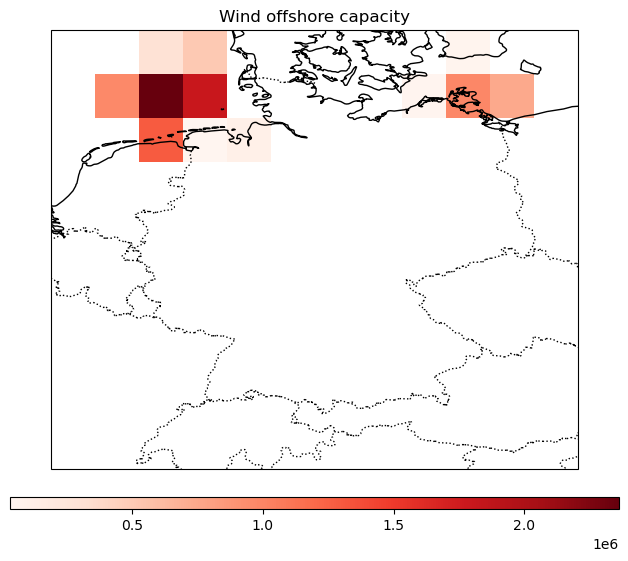

In [16]:
lon_edges = grid.lon.values - (grid.lon.diff(dim='lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges = grid.lat.values - (grid.lat.diff(dim='lat') / 2).pad({'lat': (1, 0)}, mode='edge')

# Plot the data

fig = plt.figure(figsize=(9, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# First subplot
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
im = ax.pcolormesh(lon_edges, lat_edges, grid['wind_off_cap'], transform=ccrs.PlateCarree(), cmap='Reds')
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax.set_title('Wind offshore capacity')

plt.tight_layout()
plt.show()

## Hub Height calculation

In [ ]:
# Create a grid
grid_height = grid_func.create_ref_grid('wind_off_hub_height')
# grid_height

### Calculate weighted mean (Based upon the Bruttoleistung)

In [22]:
# Drop data without height values
gdf_2 = gdf.dropna(subset=['Nabenhoehe'])
# gdf_2

In [ ]:
grid_mean_height_weighted = gdf_2.groupby(["lat_idx", "lon_idx"]).apply(lambda x: np.average(x["Nabenhoehe"], weights=x["Bruttoleistung"]))
# grid_mean_height_weighted

/tmp/ipykernel_1716471/3234131996.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grid_mean_height_weighted = gdf_2.groupby(["lat_idx", "lon_idx"]).apply(lambda x: np.average(x["Nabenhoehe"], weights=x["Bruttoleistung"]))


lat_idx  lon_idx
7        2           98.070592
         3          110.000000
         4           84.000000
8        1          100.647647
         2          100.635337
         3          101.996079
         8           67.000000
         9           97.215562
         10          99.785983
9        2           94.620000
         3           89.212766
         9           78.250000
dtype: float64

In [ ]:
# Write the sums to the grid
for (lat_idx, lon_idx), value in grid_mean_height_weighted.items():
    grid_height[lat_idx, lon_idx] = value

# Show resulting grid
# print(grid_height)

In [ ]:
# Save grid as raster file
# grid_height.to_netcdf('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_height_weighted.nc')

In [26]:
# Open File
grid = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_height_weighted.nc')
# grid

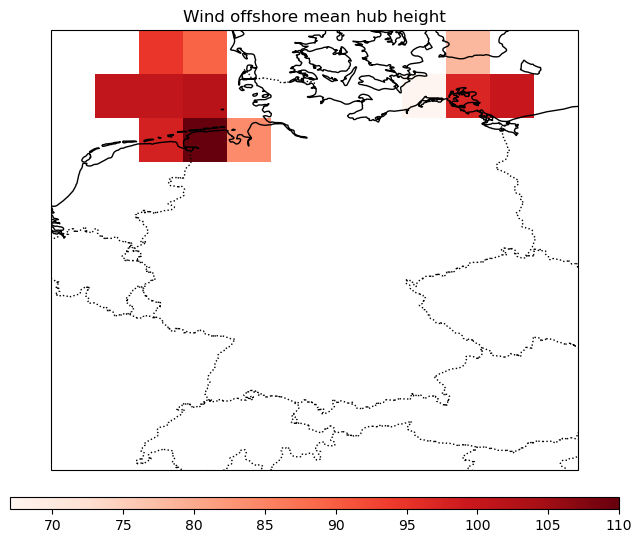

In [27]:
lon_edges = grid.lon.values - (grid.lon.diff(dim='lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges = grid.lat.values - (grid.lat.diff(dim='lat') / 2).pad({'lat': (1, 0)}, mode='edge')

# Plot the data

fig = plt.figure(figsize=(9, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# First subplot
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
im = ax.pcolormesh(lon_edges, lat_edges, grid['wind_off_hub_height'], transform=ccrs.PlateCarree(), cmap='Reds')
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax.set_title('Wind offshore mean hub height')

plt.tight_layout()
plt.show()